In [1]:
import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
import os
name_path = 'hcm_aqi_full_dataset.csv'
folder_path = 'data'

file_path = os.path.join(folder_path, name_path)

df = pd.read_csv(file_path) 
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head(5)


,time,PM10,PM2.5,CO,NO2,O3,SO2,AQI,UV,Temperature,Humidity,Rain,Wind_Speed,Wind_Dir
0,2023-01-01 00:00:00,95.0,65.0,993.0,84.4,25.0,37.5,133,0.0,23.5,65,0.0,11.3,9
1,2023-01-01 01:00:00,86.1,59.0,846.0,70.2,28.0,30.8,133,0.0,23.0,67,0.0,10.3,12
2,2023-01-01 02:00:00,83.4,57.0,821.0,65.8,26.0,28.9,132,0.0,22.5,70,0.0,7.9,360
3,2023-01-01 03:00:00,80.1,54.8,834.0,64.0,22.0,28.5,131,0.0,22.0,73,0.0,8.3,360
4,2023-01-01 04:00:00,69.4,47.5,838.0,60.1,20.0,27.2,129,0.0,21.9,72,0.0,7.9,357


In [5]:
test_size = 0.2
lags = [i for i in range(1,23)]
t = 3 
target = 'PM2.5'

# Xử lí ngoại lai

In [ ]:
# continuous_cols = ['PM10', 'PM2.5', 'CO', 'NO2', 'O3', 'SO2', 'Temperature', 'Humidity', 'Wind_Speed']

# def hampel_filter(df, column, window_size=24, n_sigmas=3):
#     # Lấy rolling window (ví dụ 24h để bao quát 1 chu kỳ ngày)
#     rolling_median = df[column].rolling(window=window_size, center=True, min_periods=1).median()
    
#     # Tính độ lệch tuyệt đối so với trung vị (MAD - Median Absolute Deviation)
#     mad = (df[column] - rolling_median).abs()
#     rolling_mad = mad.rolling(window=window_size, center=True, min_periods=1).median()
    
#     # Tính ngưỡng (1.4826 là hằng số chuẩn hóa cho phân phối chuẩn)
#     threshold = n_sigmas * 1.4826 * rolling_mad
    
#     # Cờ đánh dấu ngoại lai
#     outlier_idx = mad > threshold
    
#     # Thay thế ngoại lai bằng trung vị của cửa sổ trượt đó
#     df.loc[outlier_idx, column] = rolling_median[outlier_idx]
    
#     return df

# # Áp dụng Hampel Filter
# for col in continuous_cols:
#     df = hampel_filter(df, col, window_size=24, n_sigmas=3)

# # 2. Làm mượt dữ liệu bằng Exponential Moving Average (EWMA) (Tùy chọn bổ sung)
# # Bước này giúp dữ liệu mượt mà hơn, giảm nhiễu nhỏ để mô hình dễ học xu hướng
# # Alpha = 0.3 tương đương với việc coi trọng dữ liệu hiện tại, nhưng vẫn làm phẳng nhẹ
# for col in continuous_cols:
#     df[col] = df[col].ewm(alpha=0.3, adjust=False).mean()

# print("Đã hoàn tất xử lý ngoại lai cục bộ và làm mượt dữ liệu!")

Đã hoàn tất xử lý ngoại lai cục bộ và làm mượt dữ liệu!


C:\Users\dodac\AppData\Local\Temp\ipykernel_9648\3013639582.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[68.5 68.5 68.5 68.5 83.5 83.5 83.5 83.5 87.  87.5 85.  85.  88.  88.
 88.  82.5 84.5 84.5 88.5 89.  89.  89.5 90.  88.  88.  80.5 88.  89.
 89.  89.  89.  87.5 87.5 87.5 87.5 87.5 88.  88.  84.5 85.  85.5 87.
 89.  89.  89.  88.5 85.5 85.5 90.  88.5 89.5 90.  90.  90.  90.  90.
 90.  90.5 88.  89.5 89.5 89.5 89.5 90.  90.  90.  90.  90.  90.  90.
 90.  90.  90.  90.  90.  89.5 90.  90.  90.  90.  90.  90.  83.5 83.5
 91.  89.5 89.5 91.  91.  91.  91.  89.5 89.5 89.5 92.5 90.5 90.5 90.5
 91.5 91.5 91.5 91.5 91.5 90.5 90.5 90.5 86.  86.  86.5 86.5 87.  76.
 76.5 85.5 85.5 81.  63.5 63.  63.  63.  63.  72.  63.  63.  63.5 64.5
 67.  67.  67.5 67.5 76.5 76.5 76.5 69.  69.  71.5 72.  72.  72.  87.
 88.5 88.5 88.5 88.5 88.5 83.  81.  81.5 88.  85.5 89.  89.  89.  89.
 91.  91.  91.  91.  91.  91.  

# Xóa cột AQI

In [6]:
df = df.drop(columns=['AQI'])
df.head()

,time,PM10,PM2.5,CO,NO2,O3,SO2,UV,Temperature,Humidity,Rain,Wind_Speed,Wind_Dir
0,2023-01-01 00:00:00,95.0,65.0,993.0,84.4,25.0,37.5,0.0,23.5,65,0.0,11.3,9
1,2023-01-01 01:00:00,86.1,59.0,846.0,70.2,28.0,30.8,0.0,23.0,67,0.0,10.3,12
2,2023-01-01 02:00:00,83.4,57.0,821.0,65.8,26.0,28.9,0.0,22.5,70,0.0,7.9,360
3,2023-01-01 03:00:00,80.1,54.8,834.0,64.0,22.0,28.5,0.0,22.0,73,0.0,8.3,360
4,2023-01-01 04:00:00,69.4,47.5,838.0,60.1,20.0,27.2,0.0,21.9,72,0.0,7.9,357


# Feature thời gian và hướng gió

In [8]:
# 1. Ép kiểu cột 'time' về đúng chuẩn datetime của Pandas
df['time'] = pd.to_datetime(df['time'])

# 2. Bây giờ thì tha hồ dùng .dt
df['hour_sin'] = np.sin(2 * np.pi * df['time'].dt.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['time'].dt.hour / 24)

df['doy_sin'] = np.sin(2 * np.pi * df['time'].dt.dayofyear / 365) # Pandas bản mới dùng dayofyear thay vì day_of_year
df['doy_cos'] = np.cos(2 * np.pi * df['time'].dt.dayofyear / 365)

# 3. Tính toán hướng gió
wind_rad = np.deg2rad(df['Wind_Dir'])
df['wind_sin'] = np.sin(wind_rad)
df['wind_cos'] = np.cos(wind_rad) # SỬA LẠI THÀNH np.cos NHÉ BRO!

df.head()

,time,PM10,PM2.5,CO,NO2,O3,SO2,UV,Temperature,Humidity,Rain,Wind_Speed,Wind_Dir,hour_sin,hour_cos,doy_sin,doy_cos,wind_sin,wind_cos
0,2023-01-01 00:00:00,95.0,65.0,993.0,84.4,25.0,37.5,0.0,23.5,65,0.0,11.3,9,0.000000,1.000000,0.017213,0.999852,1.564345e-01,0.987688
1,2023-01-01 01:00:00,86.1,59.0,846.0,70.2,28.0,30.8,0.0,23.0,67,0.0,10.3,12,0.258819,0.965926,0.017213,0.999852,2.079117e-01,0.978148
2,2023-01-01 02:00:00,83.4,57.0,821.0,65.8,26.0,28.9,0.0,22.5,70,0.0,7.9,360,0.500000,0.866025,0.017213,0.999852,-2.449294e-16,1.000000
3,2023-01-01 03:00:00,80.1,54.8,834.0,64.0,22.0,28.5,0.0,22.0,73,0.0,8.3,360,0.707107,0.707107,0.017213,0.999852,-2.449294e-16,1.000000
4,2023-01-01 04:00:00,69.4,47.5,838.0,60.1,20.0,27.2,0.0,21.9,72,0.0,7.9,357,0.866025,0.500000,0.017213,0.999852,-5.233596e-02,0.998630


# Tạo lag và các biến tương lai cho PM2.5

In [9]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2'] #['PM2.5', 'PM10', 'NO2', 'CO', 'O3', 'SO2']
lag_cols_names = []
for col in pollutants:
    for lag in lags:
        col_name = f"{col}_lag_{lag}"
        df[col_name] = df[col].shift(lag) 
        lag_cols_names.append(col_name)

target_cols_names = []
for h in range(1, t+1):
    col_name = f"{target}_t+{h}"
    df[col_name] = df[target].shift(-h) # Shift âm là lấy tương lai
    target_cols_names.append(col_name)

df_clean = df.dropna().reset_index(drop=True)
print("Kích thước dữ liệu sau khi tạo lag/target và xóa NaN:", df_clean.shape)

Kích thước dữ liệu sau khi tạo lag/target và xóa NaN: (26855, 132)


C:\Users\nguye\AppData\Local\Temp\ipykernel_5312\826833514.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df[col].shift(lag)
C:\Users\nguye\AppData\Local\Temp\ipykernel_5312\826833514.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df[col].shift(lag)
C:\Users\nguye\AppData\Local\Temp\ipykernel_5312\826833514.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at 

In [10]:
df_clean = df_clean.set_index('time')
df_clean.head()

,PM10,PM2.5,CO,NO2,O3,SO2,UV,Temperature,Humidity,Rain,...,SO2_lag_16,SO2_lag_17,SO2_lag_18,SO2_lag_19,SO2_lag_20,SO2_lag_21,SO2_lag_22,PM2.5_t+1,PM2.5_t+2,PM2.5_t+3
time,,,,,,,,,,,,,,,,,,,,,
2023-01-01 22:00:00,35.5,24.6,1092.0,62.7,20.0,3.2,0.0,26.0,73,0.0,...,21.0,24.5,27.2,28.5,28.9,30.8,37.5,35.9,45.4,51.8
2023-01-01 23:00:00,51.7,35.9,1297.0,62.3,18.0,2.8,0.0,25.6,76,0.0,...,6.7,21.0,24.5,27.2,28.5,28.9,30.8,45.4,51.8,48.5
2023-01-02 00:00:00,65.2,45.4,1539.0,61.1,19.0,2.8,0.0,24.8,80,0.0,...,6.4,6.7,21.0,24.5,27.2,28.5,28.9,51.8,48.5,42.5
2023-01-02 01:00:00,74.3,51.8,1736.0,59.7,19.0,3.3,0.0,23.9,85,0.5,...,6.2,6.4,6.7,21.0,24.5,27.2,28.5,48.5,42.5,39.5
2023-01-02 02:00:00,69.8,48.5,1692.0,59.3,18.0,4.7,0.0,23.5,85,0.2,...,7.4,6.2,6.4,6.7,21.0,24.5,27.2,42.5,39.5,36.8


# Train test split

In [24]:
cols_to_drop = ['time'] + target_cols_names

X = df_clean.drop(columns=cols_to_drop, errors='ignore') 
y = df_clean[target_cols_names]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=False)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (21484, 133)
X_test shape: (5371, 133)


In [ ]:
# ==========================================
# CELL 1: XỬ LÝ ĐẶC TRƯNG (X_train, X_test)
# ==========================================
import pandas as pd

def past_hampel_filter(series, window_size=24, n_sigmas=3):
    """
    Bộ lọc Hampel CHỈ NHÌN VỀ QUÁ KHỨ để chống rò rỉ tương lai.
    Không dùng tham số center=True.
    """
    # Tính trung vị của 24h qua (bao gồm cả giờ hiện tại)
    rolling_median = series.rolling(window=window_size, min_periods=1).median()
    mad = (series - rolling_median).abs()
    rolling_mad = mad.rolling(window=window_size, min_periods=1).median()
    threshold = n_sigmas * 1.4826 * rolling_mad
    
    outlier_idx = mad > threshold
    result = series.copy()
    result.loc[outlier_idx] = rolling_median[outlier_idx]
    return result

def apply_smoothing(df, columns_to_smooth, alpha=0.3):
    """Áp dụng Hampel -> EWMA cho các cột được chỉ định"""
    df_smoothed = df.copy()
    for col in columns_to_smooth:
        # 1. Hampel Filter
        hampel_series = past_hampel_filter(df_smoothed[col])
        # 2. EWMA
        df_smoothed[col] = hampel_series.ewm(alpha=alpha, adjust=False).mean()
    return df_smoothed

# TODO: Thay thế list này bằng các cột chứa biến liên tục bạn muốn làm mượt
# Ví dụ: ['PM2.5_lag_1', 'PM2.5_lag_2', 'temperature', 'humidity']
cols_to_smooth = [col for col in X_train.columns if 'lag' in col or col in ['NhietDo', 'DoAm']]

# Áp dụng cho cả tập Train và Test
X_train = apply_smoothing(X_train, cols_to_smooth)
X_test = apply_smoothing(X_test, cols_to_smooth)

print("Đã làm mượt xong X_train và X_test!")

# Chuẩn hóa

In [25]:
cols_passthrough = [
    'is_weekend', 'hour_sin', 'hour_cos', 
    'doy_sin', 'doy_cos', 'wind_sin', 'wind_cos'
]

cols_to_scale = [c for c in X_train.columns if c not in cols_passthrough]

preprocessor = ColumnTransformer(
    transformers=[
        ('pass', 'passthrough', cols_passthrough),
        ('std', StandardScaler(), cols_to_scale)
    ],
    verbose_feature_names_out=False
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)




# Thử trên các mô hình Random Forest, Xgboost, Ridge, Lasso

In [26]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1),
    
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.1, random_state=42, n_jobs=-1),

    "Ridge Regression": Ridge(alpha=1.0),
    

    "Lasso Regression": Lasso(alpha=0.1),
    

    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
}

results = {}
metrics_list = [] # List để lưu kết quả tạo bảng

print("BẮT ĐẦU HUẤN LUYỆN VÀ ĐÁNH GIÁ CÁC MÔ HÌNH... (Vui lòng đợi)")
results = {}

print("BẮT ĐẦU HUẤN LUYỆN VÀ ĐÁNH GIÁ CÁC MÔ HÌNH:\n" + "="*50)

for name, model in models.items():
    start_time = time.time()

    multi_model = MultiOutputRegressor(model)
    multi_model.fit(X_train, y_train)
    
    y_pred_train = multi_model.predict(X_train)
    y_pred_test = multi_model.predict(X_test)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mse_test = mean_squared_error(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    
    time_taken = time.time() - start_time
    
    # Lưu kết quả vào list
    metrics_list.append({
        "Mô hình": name,
        "Thời gian (s)": round(time_taken, 2),
        "R2 Train": round(r2_train, 4),
        "R2 Test": round(r2_test, 4),
        "MSE Test": round(mse_test, 4),
        "MAE Test": round(mae_test, 4)
    })
    
    results[name] = r2_test

# Tạo DataFrame từ list kết quả và in ra
df_results = pd.DataFrame(metrics_list)
print("\nKẾT QUẢ ĐÁNH GIÁ:")
display(df_results) # Nếu dùng terminal/VSCode thuần, hãy thay bằng: print(df_results.to_markdown()) hoặc print(df_results)

best_model_name = max(results, key=results.get)
print("="*50)
print(f"🏆 Mô hình hoạt động tốt nhất trên tập Test: {best_model_name} với R2 = {results[best_model_name]:.4f}")

BẮT ĐẦU HUẤN LUYỆN VÀ ĐÁNH GIÁ CÁC MÔ HÌNH... (Vui lòng đợi)
BẮT ĐẦU HUẤN LUYỆN VÀ ĐÁNH GIÁ CÁC MÔ HÌNH:

KẾT QUẢ ĐÁNH GIÁ:


,Mô hình,Thời gian (s),R2 Train,R2 Test,MSE Test,MAE Test
0,Random Forest,45.98,0.9444,0.9189,14.3052,2.5886
1,XGBoost,3.75,0.9693,0.9398,10.6161,2.2203
2,Ridge Regression,0.11,0.9619,0.9505,8.7281,1.9095
3,Lasso Regression,51.33,0.9453,0.9279,12.7107,2.4490
4,K-Nearest Neighbors,6.43,0.9817,0.6514,61.5068,5.8912


🏆 Mô hình hoạt động tốt nhất trên tập Test: Ridge Regression với R2 = 0.9505


In [27]:
import time
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Khởi tạo TimeSeriesSplit (vẫn giữ nguyên chia 5 folds theo thời gian)
tscv = TimeSeriesSplit(n_splits=5)

# 2. Không gian tham số cho Ridge Regression
# Chúng ta sẽ thử nghiệm dải alpha từ rất nhỏ đến rất lớn (scale logarit thường hiệu quả nhất)
param_grid_ridge = {
    'estimator__alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0],
    'estimator__solver': ['auto', 'svd', 'cholesky', 'sag'] # Thử nghiệm thêm các bộ giải phương trình khác nhau
}

# 3. Khởi tạo mô hình cơ sở
ridge_base = MultiOutputRegressor(Ridge(random_state=42))

# 4. Cấu hình GridSearchCV (Quét toàn bộ không gian tham số)
grid_search_ridge = GridSearchCV(
    estimator=ridge_base,
    param_grid=param_grid_ridge,
    cv=tscv,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

# 5. Chạy tìm kiếm
print("🚀 Đang tiến hành Grid Search tinh chỉnh Ridge Regression...")
start_time = time.time()
grid_search_ridge.fit(X_train, y_train)
tuning_time = time.time() - start_time

# 6. Dự đoán và tính toán các chỉ số với mô hình tốt nhất
best_ridge = grid_search_ridge.best_estimator_
y_pred_tuned_train = best_ridge.predict(X_train)
y_pred_tuned_test = best_ridge.predict(X_test)

r2_cv = grid_search_ridge.best_score_
r2_train = r2_score(y_train, y_pred_tuned_train)
r2_test = r2_score(y_test, y_pred_tuned_test)
mse_test = mean_squared_error(y_test, y_pred_tuned_test)
mae_test = mean_absolute_error(y_test, y_pred_tuned_test)

# ==========================================
# 7. HIỂN THỊ KẾT QUẢ PANDAS
# ==========================================

# Bảng Tham số tối ưu
best_params_clean = {k.replace('estimator__', ''): [v] for k, v in grid_search_ridge.best_params_.items()}
df_params_ridge = pd.DataFrame(best_params_clean).T
df_params_ridge.columns = ['Giá trị tối ưu']
df_params_ridge.index.name = 'Tham số'

# Bảng Hiệu suất
df_metrics_ridge = pd.DataFrame([{
    "Mô hình": "Ridge (Tuned)",
    "Thời gian Tuning (s)": round(tuning_time, 2),
    "R2 Train": round(r2_train, 4),
    "R2 Test": round(r2_test, 4),
    "MSE Test": round(mse_test, 4),
    "MAE Test": round(mae_test, 4)
}])

# In ra màn hình
print("\n" + "="*50)
print("🏆 BỘ THAM SỐ TỐI ƯU NHẤT CHO RIDGE:")
display(df_params_ridge)

print("\n📊 KẾT QUẢ ĐÁNH GIÁ SAU KHI TINH CHỈNH:")
display(df_metrics_ridge)
print("="*50)

🚀 Đang tiến hành Grid Search tinh chỉnh Ridge Regression...
Fitting 5 folds for each of 44 candidates, totalling 220 fits

🏆 BỘ THAM SỐ TỐI ƯU NHẤT CHO RIDGE:


,Giá trị tối ưu
Tham số,
alpha,10.0
solver,sag



📊 KẾT QUẢ ĐÁNH GIÁ SAU KHI TINH CHỈNH:


,Mô hình,Thời gian Tuning (s),R2 Train,R2 Test,MSE Test,MAE Test
0,Ridge (Tuned),218.37,0.9616,0.9499,8.8233,1.9391


# Vì XGboost tốt nhất nên sẽ tối ưu nó

In [28]:
import time
import pandas as pd
from IPython.display import display # Import hàm display để hiển thị bảng đẹp
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# 1 -> 4. Khởi tạo và Cấu hình (Giữ nguyên như cũ)
tscv = TimeSeriesSplit(n_splits=5)

param_dist_anti_overfit = {
    'estimator__max_depth': [3, 4, 5],            
    'estimator__n_estimators': [150, 200, 300],   
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__subsample': [0.6, 0.7, 0.8],      
    'estimator__colsample_bytree': [0.6, 0.7, 0.8],
    'estimator__gamma': [0.1, 0.5, 1, 2, 5],      
    'estimator__reg_alpha': [0, 0.1, 1, 5],       
    'estimator__reg_lambda': [1, 2, 5, 10]        
}

xgb_base = MultiOutputRegressor(XGBRegressor(random_state=42, n_jobs=-1))

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_anti_overfit,
    n_iter=20,           
    cv=tscv,             
    scoring='r2', 
    verbose=1,           
    random_state=42,
    n_jobs=-1            
)

# 5. Chạy tìm kiếm
print("🚀 Đang tiến hành Random Search tìm tham số tối ưu... (Vui lòng đợi)")
start_time = time.time()
random_search.fit(X_train, y_train)
tuning_time = time.time() - start_time

# 6. Dự đoán và tính toán các chỉ số
best_model = random_search.best_estimator_
y_pred_tuned_train = best_model.predict(X_train)
y_pred_tuned_test = best_model.predict(X_test)

r2_cv = random_search.best_score_
r2_train = r2_score(y_train, y_pred_tuned_train)
r2_test = r2_score(y_test, y_pred_tuned_test)

# ==========================================
# 7. HIỂN THỊ KẾT QUẢ DƯỚI DẠNG PANDAS DATAFRAME
# ==========================================

# Tạo Bảng 1: Các tham số tối ưu
best_params_clean = {k.replace('estimator__', ''): [v] for k, v in random_search.best_params_.items()}
df_params = pd.DataFrame(best_params_clean).T
df_params.columns = ['Giá trị tối ưu']
df_params.index.name = 'Tham số'

# Tạo Bảng 2: Kết quả hiệu suất
df_metrics = pd.DataFrame([{
    "Thời gian Tuning (s)": round(tuning_time, 2),
    "R2 Cross-Validation": round(r2_cv, 4),
    "R2 Train": round(r2_train, 4),
    "R2 Test": round(r2_test, 4)
}])

# Hiển thị ra màn hình
print("\n" + "="*50)
print("🏆 BỘ THAM SỐ TỐI ƯU NHẤT XGBOOST:")
display(df_params) # Dùng display thay vì print để bảng hiện đẹp trên Jupyter

print("\n📊 KẾT QUẢ ĐÁNH GIÁ HIỆU SUẤT:")
display(df_metrics)
print("="*50)

# Nhận xét Overfitting
if r2_train - r2_test > 0.1:
    print("\n⚠️ Nhận xét: Mô hình vẫn hơi Overfitting (R2 Train > R2 Test khá nhiều).")
else:
    print("\n✅ Nhận xét: R2 Train và Test khá cân bằng, mô hình tổng quát tốt!")

🚀 Đang tiến hành Random Search tìm tham số tối ưu... (Vui lòng đợi)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

🏆 BỘ THAM SỐ TỐI ƯU NHẤT XGBOOST:


,Giá trị tối ưu
Tham số,
subsample,0.8
reg_lambda,10.0
reg_alpha,1.0
n_estimators,300.0
max_depth,3.0
learning_rate,0.1
gamma,2.0
colsample_bytree,0.7



📊 KẾT QUẢ ĐÁNH GIÁ HIỆU SUẤT:


,Thời gian Tuning (s),R2 Cross-Validation,R2 Train,R2 Test
0,128.07,0.9187,0.968,0.9383



✅ Nhận xét: R2 Train và Test khá cân bằng, mô hình tổng quát tốt!


In [29]:
xgb = XGBRegressor(
    n_estimators=300,        
    learning_rate=0.1,       
    max_depth=3,             # Cây đã được ép nông lại (từ 6 xuống 3)
    subsample=0.8,           # Thêm nhiễu bằng cách chỉ lấy 80% data cho mỗi cây
    colsample_bytree=0.7,    
    gamma=2,                 # Phạt nhánh chặt chẽ hơn (từ 0 lên 2)
    reg_alpha=1,             # L1 regularization
    reg_lambda=10,           # L2 regularization (phạt khá mạnh để chống học vẹt)
    random_state=42,
    n_jobs=-1
)

model_xgb = MultiOutputRegressor(xgb)
model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_test)

print(f"R2 Train : {r2_score(y_train, model_xgb.predict(X_train)):.4f}")
print(f"R2 Test  : {r2_score(y_test, y_pred):.4f}")
print(f"MSE Test : {mean_squared_error(y_test, y_pred):.4f} | MAE Test: {mean_absolute_error(y_test, y_pred):.4f}")


R2 Train : 0.9680
R2 Test  : 0.9383
MSE Test : 10.8737 | MAE Test: 2.2630


# Kết quả của t+1, t+2, t+3

In [30]:
# Tính dự đoán trên tập train 
y_pred_train = model_xgb.predict(X_train)

# Tính metrics cho tập Train
r2_train = r2_score(y_train, y_pred_train, multioutput='raw_values')
mae_train = mean_absolute_error(y_train, y_pred_train, multioutput='raw_values')
mse_train = mean_squared_error(y_train, y_pred_train, multioutput='raw_values')
rmse_train = np.sqrt(mse_train)

# Tính metrics cho tập Test
r2_test = r2_score(y_test, y_pred, multioutput='raw_values')
mae_test = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
mse_test = mean_squared_error(y_test, y_pred, multioutput='raw_values')
rmse_test = np.sqrt(mse_test)

# Tạo DataFrame tổng hợp
metrics_df = pd.DataFrame({
    'Dự báo': [f't + {i+1}' for i in range(3)],
    'R2_Train': r2_train,
    'R2_Test': r2_test,
    'MAE_Train': mae_train,
    'MAE_Test': mae_test,
    'MSE_Train': mse_train,
    'MSE_Test': mse_test,
    'RMSE_Train': rmse_train,
    'RMSE_Test': rmse_test
})

# Đặt cột 'Dự báo' làm index và làm tròn 4 chữ số thập phân
metrics_df = metrics_df.set_index('Dự báo').round(4)

# Hiển thị bảng
metrics_df

,R2_Train,R2_Test,MAE_Train,MAE_Test,MSE_Train,MSE_Test,RMSE_Train,RMSE_Test
Dự báo,,,,,,,,
t + 1,0.9912,0.9815,0.7419,1.2146,1.1483,3.273500,1.0716,1.8093
t + 2,0.9708,0.9449,1.4025,2.2696,3.8305,9.724800,1.9572,3.1185
t + 3,0.9419,0.8886,2.0050,3.3049,7.6405,19.622801,2.7641,4.4298


In [33]:
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

# 1. Khởi tạo trực tiếp mô hình với tham số tối ưu (đỡ tốn thời gian chạy lại tuning)
best_ridge_model = MultiOutputRegressor(Ridge(alpha=10.0, solver='sag', random_state=42))

# 2. Huấn luyện lại trên tập Train
best_ridge_model.fit(X_train, y_train)

# 3. Dự đoán
y_pred_tuned_train = best_ridge_model.predict(X_train)
y_pred_tuned_test = best_ridge_model.predict(X_test)

# ---> DÁN ĐOẠN CODE TẠO BẢNG T+1, T+2 Ở TIN NHẮN TRƯỚC VÀO ĐÂY <---


# --- CHUẨN BỊ DỮ LIỆU ĐỂ TẠO BẢNG ---

metrics_per_step = []
step_names = []

# Lấy số lượng output (số bước thời gian bạn đang dự báo, ví dụ: 3)
# Xử lý an toàn cho cả trường hợp y_train là Numpy Array hoặc Pandas DataFrame
n_outputs = y_train.shape[1] if len(y_train.shape) > 1 else 1

for i in range(n_outputs):
    # Trích xuất dữ liệu thực tế của từng bước
    y_true_train_step = y_train.iloc[:, i] if hasattr(y_train, 'iloc') else y_train[:, i]
    y_true_test_step = y_test.iloc[:, i] if hasattr(y_test, 'iloc') else y_test[:, i]
    
    # Trích xuất dữ liệu dự đoán của từng bước
    y_pred_train_step = y_pred_tuned_train[:, i]
    y_pred_test_step = y_pred_tuned_test[:, i]

    # Tính toán các chỉ số
    mse_train_step = mean_squared_error(y_true_train_step, y_pred_train_step)
    mse_test_step = mean_squared_error(y_true_test_step, y_pred_test_step)
    
    metrics_per_step.append({
        'R2_Train': r2_score(y_true_train_step, y_pred_train_step),
        'R2_Test': r2_score(y_true_test_step, y_pred_test_step),
        'MAE_Train': mean_absolute_error(y_true_train_step, y_pred_train_step),
        'MAE_Test': mean_absolute_error(y_true_test_step, y_pred_test_step),
        'MSE_Train': mse_train_step,
        'MSE_Test': mse_test_step,
        'RMSE_Train': np.sqrt(mse_train_step),
        'RMSE_Test': np.sqrt(mse_test_step)
    })
    
    # Tạo tên Index (t + 1, t + 2,...)
    step_names.append(f't + {i + 1}')

# --- TẠO VÀ FORMAT BẢNG PANDAS ---

df_step_metrics = pd.DataFrame(metrics_per_step, index=step_names)
df_step_metrics.index.name = 'Dự báo'

# Định dạng hiển thị số chữ số thập phân giống hệt trong ảnh bạn gửi
format_dict = {
    'R2_Train': '{:.4f}', 'R2_Test': '{:.4f}',
    'MAE_Train': '{:.4f}', 'MAE_Test': '{:.4f}',
    'MSE_Train': '{:.6f}', 'MSE_Test': '{:.6f}',
    'RMSE_Train': '{:.4f}', 'RMSE_Test': '{:.4f}'
}

print("\n📊 CHI TIẾT KẾT QUẢ DỰ BÁO THEO TỪNG BƯỚC THỜI GIAN (RIDGE TUNED):")
# Dùng df.style.format để áp dụng định dạng mà không làm thay đổi giá trị thực của DataFrame
display(df_step_metrics.style.format(format_dict))


📊 CHI TIẾT KẾT QUẢ DỰ BÁO THEO TỪNG BƯỚC THỜI GIAN (RIDGE TUNED):


,R2_Train,R2_Test,MAE_Train,MAE_Test,MSE_Train,MSE_Test,RMSE_Train,RMSE_Test
Dự báo,,,,,,,,
t + 1,0.9918,0.9897,0.6326,0.8842,1.069300,1.824163,1.0341,1.3506
t + 2,0.9669,0.9573,1.3935,1.9355,4.345208,7.540720,2.0845,2.7460
t + 3,0.9261,0.9029,2.1419,2.9975,9.712200,17.105105,3.1164,4.1358


C:\Users\dodac\AppData\Local\Temp\ipykernel_9648\112693073.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df.head(20), palette='viridis')


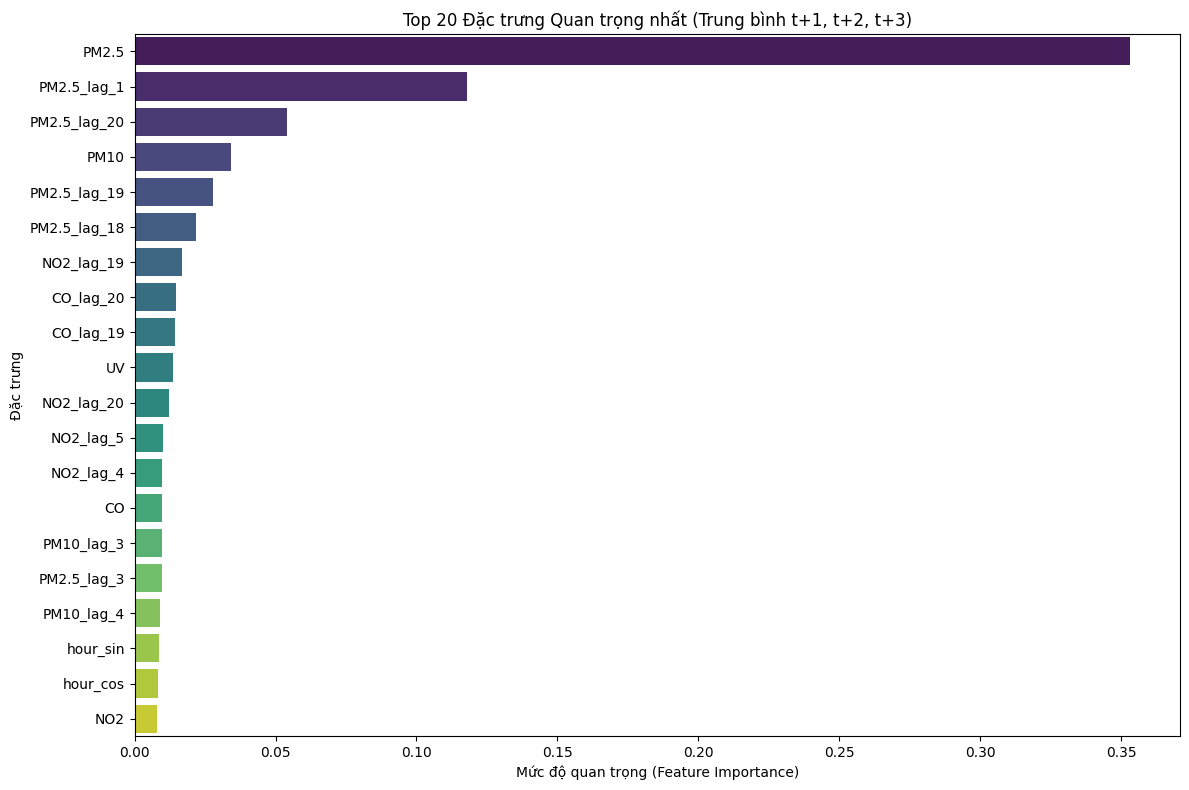


Danh sách 20 biến ÍT QUAN TRỌNG NHẤT (có thể xem xét loại bỏ):


,Feature,Importance
113,CO_lag_1,0.001167
114,PM2.5_lag_6,0.001143
115,SO2_lag_1,0.001112
116,CO_lag_16,0.001099
117,CO_lag_18,0.001039
118,SO2_lag_21,0.001013
119,PM10_lag_21,0.001013
120,PM10_lag_19,0.000989
121,CO_lag_15,0.000981
122,PM2.5_lag_22,0.000963


In [34]:


# 1. Lấy tên các đặc trưng sau khi đi qua ColumnTransformer
feature_names = preprocessor.get_feature_names_out()

# 2. Lấy feature importances từ các mô hình XGBoost con trong MultiOutputRegressor
# model_xgb.estimators_ chứa 3 mô hình dự báo cho t+1, t+2, t+3
importances = np.mean([est.feature_importances_ for est in model_xgb.estimators_], axis=0)

# 3. Tạo DataFrame để lưu trữ và sắp xếp
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sắp xếp giảm dần theo mức độ quan trọng
fi_df = fi_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 4. Trực quan hóa Top 20 biến QUAN TRỌNG NHẤT
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(20), palette='viridis')
plt.title('Top 20 Đặc trưng Quan trọng nhất (Trung bình t+1, t+2, t+3)')
plt.xlabel('Mức độ quan trọng (Feature Importance)')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show()

# 5. In ra danh sách các biến ÍT QUAN TRỌNG NHẤT để xem xét loại bỏ
print("\nDanh sách 20 biến ÍT QUAN TRỌNG NHẤT (có thể xem xét loại bỏ):")
display(fi_df.tail(20))